<a href="https://colab.research.google.com/github/FransTechWorld/FransTechWorld/blob/main/Previs%C3%A3o_de_demanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pycaret-ts-alpha

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.1/468.1 KB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 78.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 56.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 KB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 KB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 79.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.7/147.7 KB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 KB 27.

In [3]:
import pandas as pd

In [4]:
dt = pd.read_excel('/content/Dados.xlsx')

In [5]:
dt

,Data,Vendas
0,2022-12-06,870
1,2022-12-07,868
2,2022-12-08,1189
3,2022-12-09,742
4,2022-12-10,317
5,2022-12-11,685
6,2022-12-12,1366
7,2022-12-13,1213
8,2022-12-14,1055
9,2022-12-15,1343


In [7]:
dt['Data'] = pd.to_datetime(dt['Data'])

In [8]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Data    46 non-null     datetime64[ns]
 1   Vendas  46 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 864.0 bytes


In [13]:
dt.set_index('Data', drop=True, inplace=True)

In [23]:
dt

,Vendas
Data,
2022-12-06,870
2022-12-07,868
2022-12-08,1189
2022-12-09,742
2022-12-10,317
2022-12-11,685
2022-12-12,1366
2022-12-13,1213
2022-12-14,1055


In [37]:
!pip install matplotlib==3.6.3

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


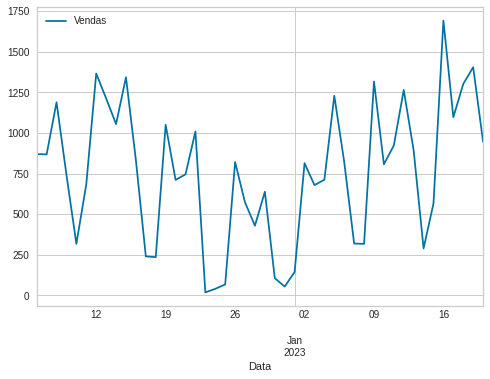

In [36]:
dt.plot()

In [38]:
from pycaret.time_series import *

In [55]:
setup(dt, fh=5, fold=8, seasonal_period='D')

INFO:logs:PyCaret TSForecastingExperiment
INFO:logs:Logging name: ts-default-name
INFO:logs:ML Usecase: MLUsecase.TIME_SERIES
INFO:logs:version 3.0.0
INFO:logs:Initializing setup()
INFO:logs:self.USI: 48e6
INFO:logs:self.variable_keys: {'_all_metrics', 'log_plots_param', 'exogenous_present', 'y_test_transformed', 'gpu_param', 'y_train', 'enforce_exogenous', 'y', 'X_transformed', 'all_sp_values', 'exp_id', 'master_model_container', 'html_param', 'exp_name_log', '_all_models', '_all_models_internal', 'pipeline', '_gpu_n_jobs_param', 'data', 'experiment__', 'USI', 'X_test_transformed', 'memory', 'n_jobs_param', 'fh', 'X_test', 'idx', 'approach_type', 'seasonal_period', 'primary_sp_to_use', 'logging_param', 'strictly_positive', 'index_type', 'X_train_transformed', 'y_transformed', '_ml_usecase', 'display_container', 'X', 'X_train', 'fold_groups_param_full', 'fold_param', 'seed', 'enforce_pi', '_available_plots', 'variable_keys', 'seasonality_present', 'y_train_transformed', 'y_test', 'fold

,Description,Value
0,session_id,8080
1,Target,Vendas
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Data shape,"(46, 1)"
5,Train data shape,"(41, 1)"
6,Test data shape,"(5, 1)"
7,Fold Generator,ExpandingWindowSplitter
8,Fold Number,8
9,Enforce Prediction Interval,False


INFO:logs:setup() successfully completed in 0.29s...............


In [48]:
best_model = compare_models()

,Model,MAE,RMSE,MAPE,SMAPE,MASE,RMSSE,R2,TT (Sec)
arima,ARIMA,120.97,160.999,0.1752,0.1935,0.4593,0.4932,0.7896,0.100
auto_arima,Auto ARIMA,162.3438,215.9448,0.2341,0.3055,0.6042,0.6499,0.5426,4.370
theta,Theta Forecaster,220.2879,267.2305,0.3375,0.4418,0.8295,0.8129,0.4226,0.065
grand_means,Grand Means Forecaster,318.6203,363.5002,0.5572,0.4632,1.2021,1.1068,-0.0619,0.025
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Det...,252.2748,306.7908,0.3552,0.4727,0.9571,0.9384,0.244,0.075
croston,Croston,325.5024,370.9834,0.5371,0.4746,1.2286,1.1299,-0.1046,0.030
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,244.4542,288.2918,0.3561,0.4803,0.9275,0.8817,0.333,0.220
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,247.4052,296.2255,0.3661,0.5023,0.9386,0.9051,0.2982,0.100
naive,Naive Forecaster,415.8,484.0465,0.9618,0.521,1.5835,1.4859,-0.9446,0.025
snaive,Seasonal Naive Forecaster,238.1,285.2723,0.3668,0.5391,0.912,0.8798,0.2659,0.025


INFO:logs:master_model_container: 27
INFO:logs:display_container: 2
INFO:logs:ARIMA(seasonal_order=(0, 1, 0, 7))
INFO:logs:compare_models() successfully completed......................................


In [56]:
modelo = create_model('auto_arima')

,cutoff,MAE,RMSE,MAPE,SMAPE,MASE,RMSSE,R2
0,2022-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-12-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-12-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-12-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-12-26,143.6448,170.5103,0.7024,0.9564,0.4818,0.4843,0.4902
5,2022-12-31,194.0972,210.7622,0.4651,0.3372,0.7228,0.6495,0.6307
6,2023-01-05,99.0918,138.0050,0.1210,0.1305,0.3856,0.4322,0.8634
7,2023-01-10,225.5959,293.8845,0.3472,0.4804,0.8228,0.8675,0.2217
Mean,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


INFO:logs:master_model_container: 1
INFO:logs:display_container: 2
INFO:logs:AutoARIMA(random_state=8080, sp=7, suppress_warnings=True)
INFO:logs:create_model() successfully completed......................................


In [42]:
plot_model(modelo, plot='decomp_stl')

INFO:logs:Visual Rendered Successfully


In [57]:
plot_model(modelo, plot='train_test_split')

INFO:logs:Visual Rendered Successfully


In [58]:
final = finalize_model(modelo)

INFO:logs:Initializing finalize_model()
INFO:logs:finalize_model(self=<pycaret.time_series.forecasting.oop.TSForecastingExperiment object at 0x7fc26b2686a0>, estimator=AutoARIMA(random_state=8080, sp=7, suppress_warnings=True), fit_kwargs=None, groups=None, model_only=True, experiment_custom_tags=None, display=None)
INFO:logs:Finalizing AutoARIMA(random_state=8080, sp=7, suppress_warnings=True)
INFO:logs:Initializing create_model()
INFO:logs:create_model(self=<pycaret.time_series.forecasting.oop.TSForecastingExperiment object at 0x7fc26b2686a0>, estimator=AutoARIMA(random_state=8080, sp=7, suppress_warnings=True), fold=None, round=4, cross_validation=True, predict=True, fit_kwargs={}, groups=None, refit=True, probability_threshold=None, experiment_custom_tags=None, verbose=False, system=False, add_to_model_list=False, metrics=None, display=None, kwargs={})
INFO:logs:Checking exceptions
INFO:logs:Importing libraries
INFO:logs:Copying training dataset
INFO:logs:Defining folds
INFO:logs:D

In [59]:
final

AutoARIMA(random_state=8080, sp=7, suppress_warnings=True)

In [60]:
plot_model(final, plot='forecast')

INFO:logs:Visual Rendered Successfully
